<a href="https://colab.research.google.com/github/Dexter0013/Vision-Transformer/blob/main/HERA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.system('mv /content/kaggle (1).json /root/.kaggle/kaggle.json')
os.system('chmod 600 /root/.kaggle/kaggle.json')  # restricts read access, Kaggle CLI requires this

256

In [1]:
from google.colab import userdata
import os, json

os.makedirs('/root/.kaggle', exist_ok=True)
creds = {
    "username": userdata.get('KAGGLE_USERNAME'),
    "key": userdata.get('KAGGLE_KEY')
}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(creds, f)
os.system('chmod 600 /root/.kaggle/kaggle.json')

0

In [ ]:
# 1. Install kaggle CLI
!pip install -q kaggle

# 2. Set up credentials (assuming you already uploaded kaggle.json — see previous steps)
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('mv kaggle.json /root/.kaggle/kaggle.json')
os.system('chmod 600 /root/.kaggle/kaggle.json')

# 3. Download the HMDB51 mirror
!kaggle datasets download -d easonlll/hmdb51 -p /content/data

# 4. Unzip
!unzip -q /content/data/hmdb51.zip -d /content/data/hmdb51

# 5. Check structure
import os
print(os.listdir('/content/data/hmdb51'))

Dataset URL: https://www.kaggle.com/datasets/easonlll/hmdb51
License(s): unknown
100% 3.14G/3.14G [00:37<00:00, 89.6MB/s]

['HMDB51']


In [ ]:
# --- Step 3: Build stratified 5% subset ---
def build_test_subset(dataset_dir, output_dir, fraction=0.05, min_per_class=2, seed=42):
    random.seed(seed)
    dataset_dir = Path(dataset_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    summary = {}
    for class_dir in sorted(dataset_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        videos = list(class_dir.glob("*"))
        if not videos:
            continue
        n_take = max(min_per_class, int(len(videos) * fraction))
        n_take = min(n_take, len(videos))
        sampled = random.sample(videos, n_take)

        out_class_dir = output_dir / class_dir.name
        out_class_dir.mkdir(parents=True, exist_ok=True)
        for video in sampled:
            link_path = out_class_dir / video.name
            if not link_path.exists():
                os.symlink(video.resolve(), link_path)

        summary[class_dir.name] = n_take

    print(f"Subset built at {output_dir}")
    print(f"Total classes: {len(summary)}, total clips: {sum(summary.values())}")
    for cls, n in summary.items():
        print(f"  {cls}: {n} clips")
    return summary

# Adjust this path once you've confirmed the real class-folder location from Step 2
summary = build_test_subset(
    dataset_dir="/content/data/hmdb51/HMDB51",   # <-- update this path
    output_dir="/content/hmdb51_5pct",
    fraction=0.05,
    min_per_class=2
)

Subset built at /content/hmdb51_5pct
Total classes: 51, total clips: 320
  brush_hair: 5 clips
  cartwheel: 5 clips
  catch: 5 clips
  chew: 5 clips
  clap: 6 clips
  climb: 5 clips
  climb_stairs: 5 clips
  dive: 6 clips
  draw_sword: 5 clips
  dribble: 7 clips
  drink: 8 clips
  eat: 5 clips
  fall_floor: 6 clips
  fencing: 5 clips
  flic_flac: 5 clips
  golf: 5 clips
  handstand: 5 clips
  hit: 6 clips
  hug: 5 clips
  jump: 7 clips
  kick: 6 clips
  kick_ball: 6 clips
  kiss: 5 clips
  laugh: 6 clips
  pick: 5 clips
  pour: 5 clips
  pullup: 5 clips
  punch: 6 clips
  push: 5 clips
  pushup: 5 clips
  ride_bike: 5 clips
  ride_horse: 5 clips
  run: 11 clips
  shake_hands: 8 clips
  shoot_ball: 6 clips
  shoot_bow: 5 clips
  shoot_gun: 5 clips
  sit: 7 clips
  situp: 5 clips
  smile: 5 clips
  smoke: 5 clips
  somersault: 7 clips
  stand: 7 clips
  swing_baseball: 7 clips
  sword: 6 clips
  sword_exercise: 6 clips
  talk: 6 clips
  throw: 5 clips
  turn: 12 clips
  walk: 27 clips
  

In [2]:
# 1. Setup Kaggle credentials (skip if already done)
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('mv kaggle.json /root/.kaggle/kaggle.json')
os.system('chmod 600 /root/.kaggle/kaggle.json')

# 2. Download
!kaggle datasets download -d matthewjansen/ucf101-action-recognition -p /content/data
!unzip -q /content/data/ucf101-action-recognition.zip -d /content/data/ucf101

# 3. Check structure
import os
print(os.listdir('/content/data/ucf101'))

Dataset URL: https://www.kaggle.com/datasets/matthewjansen/ucf101-action-recognition
License(s): CC0-1.0
100% 6.53G/6.53G [05:25<00:00, 21.5MB/s]

['val', 'val.csv', 'test.csv', 'train.csv', 'train', 'test']


In [3]:
import random
import os
from pathlib import Path

# --- Step 3: Build stratified 5% subset ---
def build_test_subset(dataset_dir, output_dir, fraction=0.05, min_per_class=2, seed=42):
    random.seed(seed)
    dataset_dir = Path(dataset_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    summary = {}
    for class_dir in sorted(dataset_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        videos = list(class_dir.glob("*"))
        if not videos:
            continue
        n_take = max(min_per_class, int(len(videos) * fraction))
        n_take = min(n_take, len(videos))
        sampled = random.sample(videos, n_take)

        out_class_dir = output_dir / class_dir.name
        out_class_dir.mkdir(parents=True, exist_ok=True)
        for video in sampled:
            link_path = out_class_dir / video.name
            if not link_path.exists():
                os.symlink(video.resolve(), link_path)

        summary[class_dir.name] = n_take

    print(f"Subset built at {output_dir}")
    print(f"Total classes: {len(summary)}, total clips: {sum(summary.values())})")
    for cls, n in summary.items():
        print(f"  {cls}: {n} clips")
    return summary

summary = build_test_subset(
    dataset_dir="/content/data/ucf101/train",   # adjust based on actual unzipped structure
    output_dir="/content/ucf101_5pct",
    fraction=0.05,
    min_per_class=2
)

Subset built at /content/ucf101_5pct
Total classes: 101, total clips: 456)
  ApplyEyeMakeup: 5 clips
  ApplyLipstick: 4 clips
  Archery: 5 clips
  BabyCrawling: 4 clips
  BalanceBeam: 4 clips
  BandMarching: 5 clips
  BaseballPitch: 5 clips
  Basketball: 9 clips
  BasketballDunk: 4 clips
  BenchPress: 6 clips
  Biking: 5 clips
  Billiards: 5 clips
  BlowDryHair: 4 clips
  BlowingCandles: 4 clips
  BodyWeightSquats: 4 clips
  Bowling: 5 clips
  BoxingPunchingBag: 6 clips
  BoxingSpeedBag: 5 clips
  BreastStroke: 3 clips
  BrushingTeeth: 4 clips
  CleanAndJerk: 4 clips
  CliffDiving: 5 clips
  CricketBowling: 5 clips
  CricketShot: 6 clips
  CuttingInKitchen: 4 clips
  Diving: 5 clips
  Drumming: 6 clips
  Fencing: 4 clips
  FieldHockeyPenalty: 4 clips
  FloorGymnastics: 4 clips
  FrisbeeCatch: 4 clips
  FrontCrawl: 5 clips
  GolfSwing: 5 clips
  Haircut: 4 clips
  HammerThrow: 5 clips
  Hammering: 5 clips
  HandstandPushups: 4 clips
  HandstandWalking: 4 clips
  HeadMassage: 5 clips
  H

In [4]:
!pip install -q git+https://github.com/facebookresearch/hiera.git
# or: pip install hiera-transformer

import torch
import hiera

# Load pretrained video Hiera (Kinetics-400 finetuned)
model = torch.hub.load("facebookresearch/hiera", "hiera_base_16x224", pretrained=True, checkpoint="mae_k400_ft_k400")
model.eval()
model = model.cuda() if torch.cuda.is_available() else model

  Preparing metadata (setup.py) ... done


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Downloading: "https://github.com/facebookresearch/hiera/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/hiera/hiera_base_16x224.pth" to /root/.cache/torch/hub/checkpoints/hiera_base_16x224.pth


100%|██████████| 585M/585M [00:30<00:00, 20.4MB/s]


In [5]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F

def load_video_clip(video_path, num_frames=16, size=224):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # evenly sample num_frames indices across the whole clip
    indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    frames = []
    frame_idx = 0
    idx_set = set(indices)
    while cap.isOpened() and len(frames) < num_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx in idx_set:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (size, size))
            frames.append(frame)
        frame_idx += 1
    cap.release()

    # pad if video was shorter than expected
    while len(frames) < num_frames:
        frames.append(frames[-1])

    clip = np.stack(frames)  # (T, H, W, C)
    clip = torch.from_numpy(clip).float() / 255.0
    clip = clip.permute(3, 0, 1, 2)  # -> (C, T, H, W)

    # normalize (ImageNet stats, standard for Hiera)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1, 1)
    clip = (clip - mean) / std

    return clip.unsqueeze(0)  # add batch dim -> (1, C, T, H, W)

Info: OpenCV successfully opened video file at /content/ucf101_5pct/Diving/v_Diving_g02_c04.avi. Proceeding with load_video_clip.
Top-5 predicted classes (Kinetics-400 indices): tensor([[329, 325, 172, 308,  49]], device='cuda:0')
Top-5 probabilities: tensor([[0.0055, 0.0028, 0.0025, 0.0025, 0.0025]], device='cuda:0')


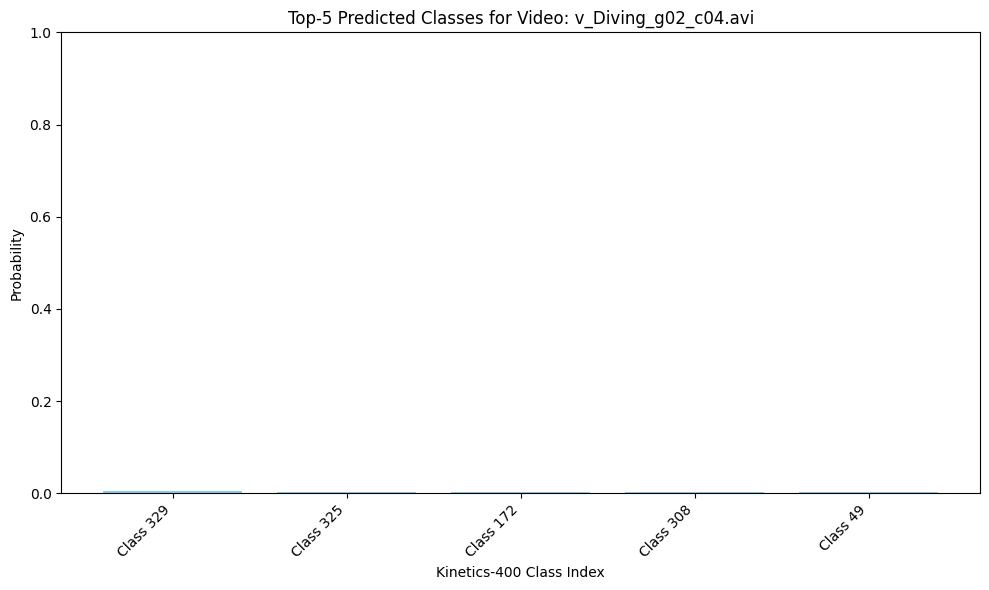

In [6]:
import os
import cv2
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Corrected video_path to point to the location where the subset was created
video_path = "/content/ucf101_5pct/Diving/v_Diving_g02_c04.avi"

if not os.path.exists(video_path):
    print(f"Error: Video file not found at {video_path}. Please check the path and ensure the dataset is correctly extracted and symlinks are valid.")
elif os.path.getsize(video_path) == 0:
    print(f"Error: Video file at {video_path} is empty (0 bytes). It might be corrupted or incorrectly downloaded.")
else:
    cap_test = cv2.VideoCapture(video_path)
    if not cap_test.isOpened():
        print(f"Error: OpenCV could not open video file at {video_path}. This might indicate a corrupted file or missing video codecs.")
        cap_test.release()
    else:
        print(f"Info: OpenCV successfully opened video file at {video_path}. Proceeding with load_video_clip.")
        cap_test.release()
        try:
            clip = load_video_clip(video_path)
            clip = clip.cuda() if torch.cuda.is_available() else clip

            with torch.no_grad():
                output = model(clip)
                probs = F.softmax(output, dim=-1)
                top5 = torch.topk(probs, k=5)

            print("Top-5 predicted classes (Kinetics-400 indices):", top5.indices)
            print("Top-5 probabilities:", top5.values)

            # --- Plotting the results ---
            # Move to CPU and convert to numpy for plotting
            indices = top5.indices.squeeze().cpu().numpy()
            probabilities = top5.values.squeeze().cpu().numpy()

            # Create labels for the x-axis (e.g., 'Class 37', 'Class 84')
            labels = [f"Class {idx}" for idx in indices]

            # Create the bar plot
            plt.figure(figsize=(10, 6))
            plt.bar(labels, probabilities, color='skyblue')
            plt.xlabel("Kinetics-400 Class Index")
            plt.ylabel("Probability")
            plt.title(f"Top-5 Predicted Classes for Video: {os.path.basename(video_path)}")
            plt.ylim(0, 1) # Probabilities are between 0 and 1
            plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
            plt.tight_layout() # Adjust layout to prevent labels from overlapping
            plt.show()

        except IndexError as e:
            print(f"Specific Error: load_video_clip failed with IndexError: {e}. This means no frames were successfully read from the video by the function. The video file might be unreadable or contain no playable frames.")
        except Exception as e:
            print(f"An unexpected error occurred during video processing: {e}")

In [7]:
import requests

# URL for Kinetics-400 class names
KINETICS_LABELS_URL = "https://raw.githubusercontent.com/deepmind/kinetics-i3d/master/data/label_map.txt"

# Download the label map file
try:
    response = requests.get(KINETICS_LABELS_URL)
    response.raise_for_status()  # Raise an exception for HTTP errors
    with open("kinetics_400_labels.txt", "w") as f:
        f.write(response.text)
    print("Kinetics-400 label map downloaded successfully.")
except requests.exceptions.RequestException as e:
    print(f"Error downloading Kinetics-400 label map: {e}")
    print("Please ensure you have an active internet connection or try again later.")

# Load the labels
kinetics_labels = []
try:
    with open("kinetics_400_labels.txt", "r") as f:
        for line in f:
            kinetics_labels.append(line.strip())
    print(f"Loaded {len(kinetics_labels)} Kinetics-400 class labels.")
except FileNotFoundError:
    print("Kinetics-400 label map file not found. Please ensure it was downloaded correctly.")
except Exception as e:
    print(f"Error loading Kinetics-400 label map: {e}")

Kinetics-400 label map downloaded successfully.
Loaded 400 Kinetics-400 class labels.


Info: OpenCV successfully opened video file at /content/ucf101_5pct/BoxingPunchingBag/v_BoxingPunchingBag_g06_c04.avi. Proceeding with load_video_clip.
Top-5 predicted classes (Kinetics-400 indices): tensor([[258, 259, 152, 302, 150]], device='cuda:0')
Top-5 probabilities:  tensor([[0.0039, 0.0036, 0.0025, 0.0025, 0.0025]], device='cuda:0')


/tmp/ipykernel_812/3370049886.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[len(display_frames)].set_xticklabels(class_names, rotation=45, ha='right') # Apply ha='right' here


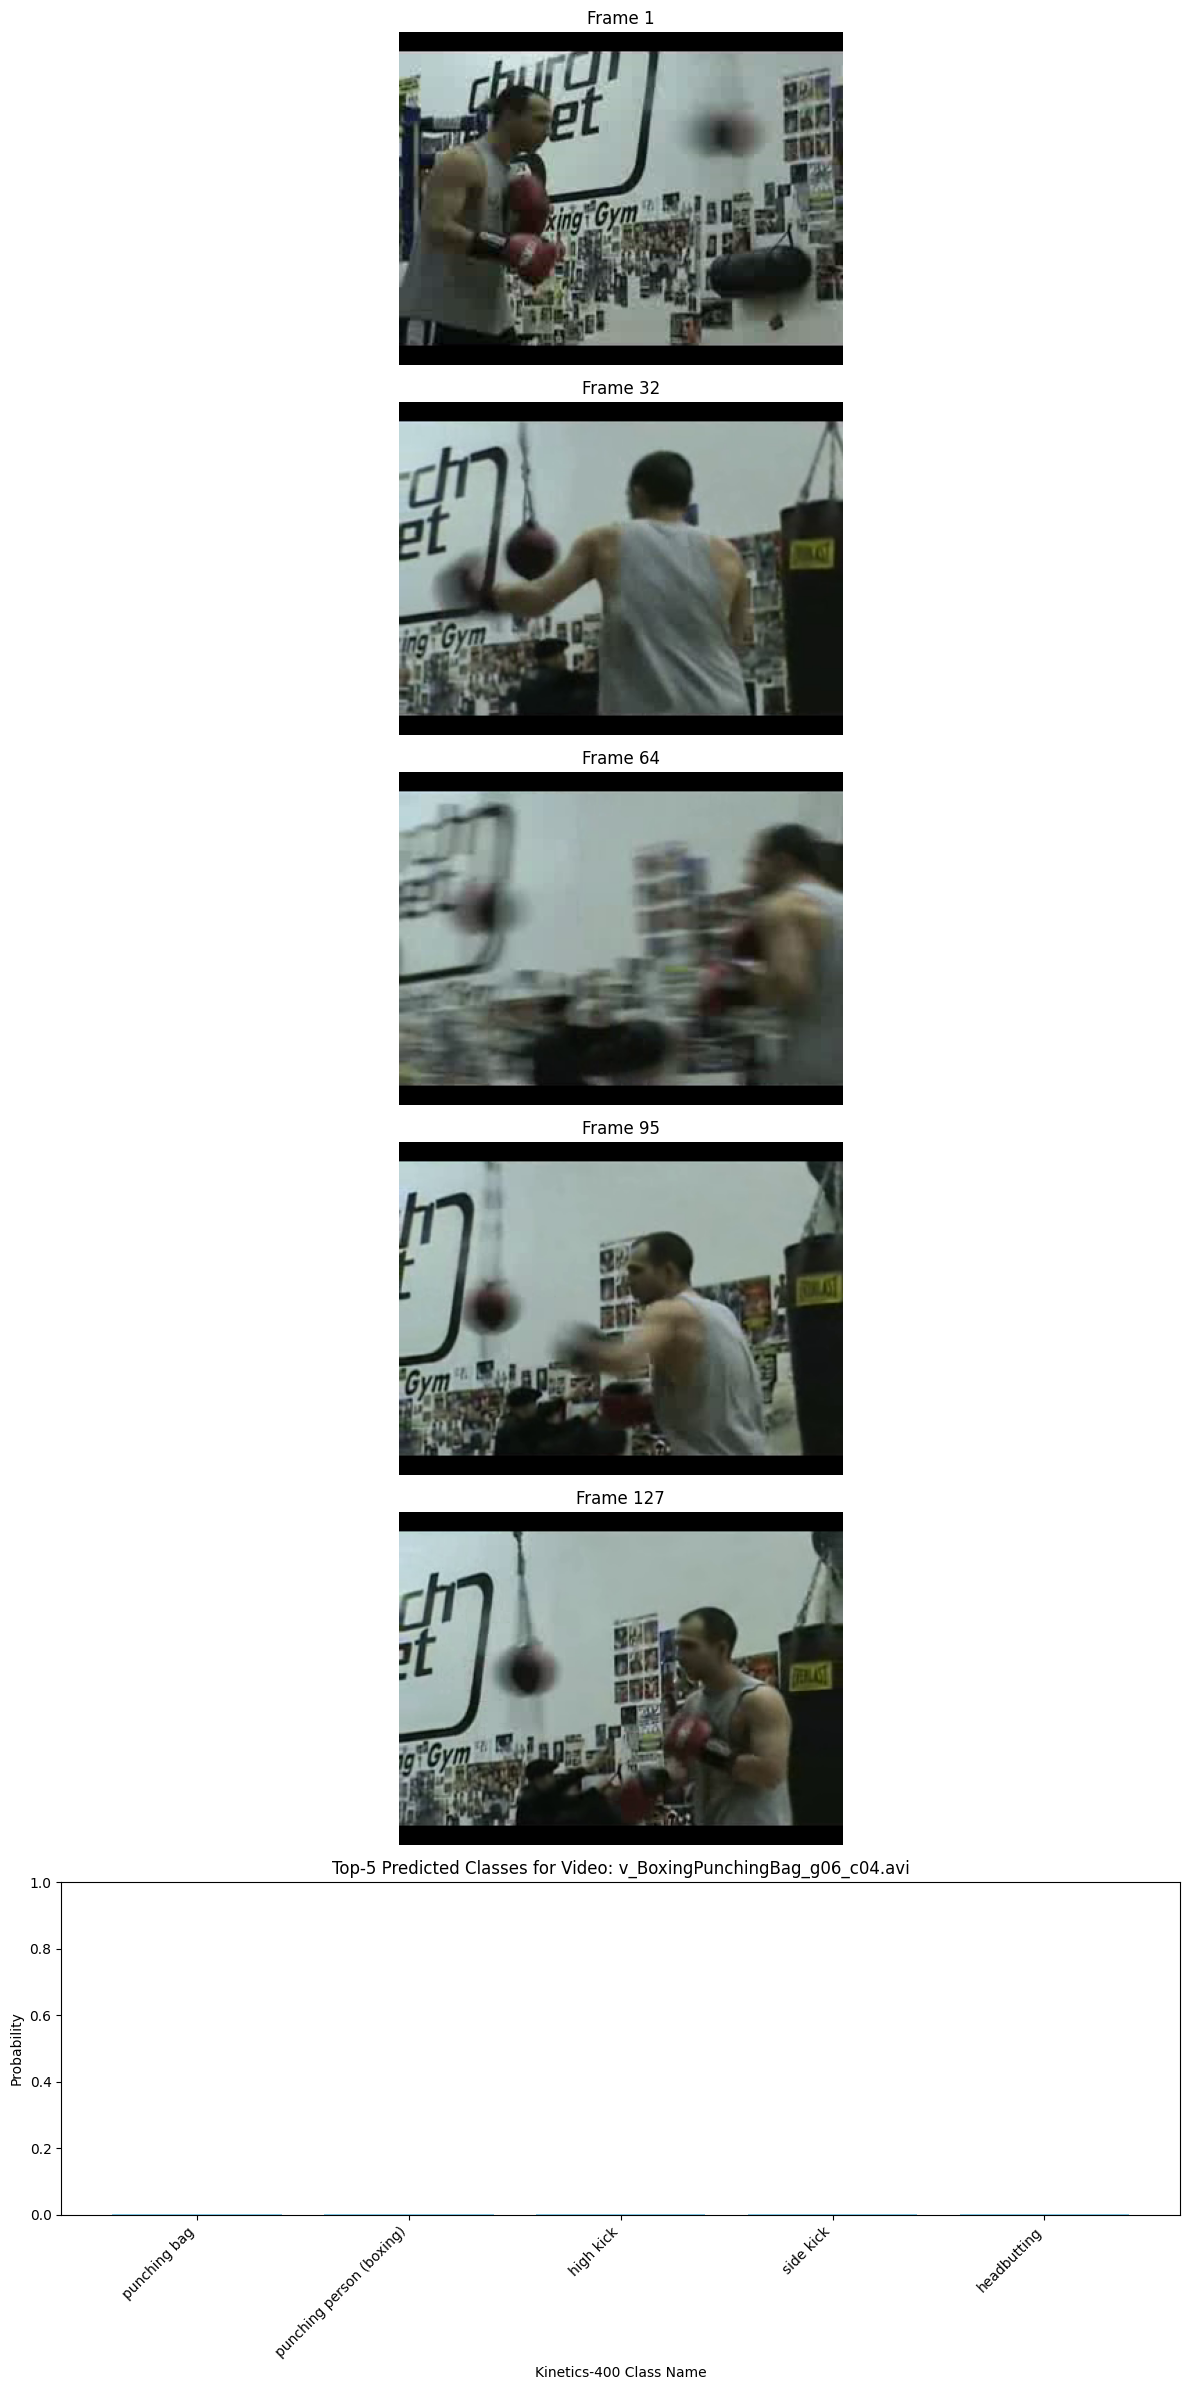

In [12]:
# Re-run the inference and plotting with class names
import os
import cv2
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np # Add numpy import

video_path = "/content/ucf101_5pct/BoxingPunchingBag/v_BoxingPunchingBag_g06_c04.avi" # Changed video path

if not os.path.exists(video_path):
    print(f"Error: Video file not found at {video_path}. Please check the path and ensure the dataset is correctly extracted and symlinks are valid.")
elif os.path.getsize(video_path) == 0:
    print(f"Error: Video file at {video_path} is empty (0 bytes). It might be corrupted or incorrectly downloaded.")
else:
    cap_test = cv2.VideoCapture(video_path)
    if not cap_test.isOpened():
        print(f"Error: OpenCV could not open video file at {video_path}. This might indicate a corrupted file or missing video codecs.")
        cap_test.release()
    else:
        print(f"Info: OpenCV successfully opened video file at {video_path}. Proceeding with load_video_clip.")
        cap_test.release()
        try:
            clip = load_video_clip(video_path)
            clip = clip.cuda() if torch.cuda.is_available() else clip

            with torch.no_grad():
                output = model(clip)
                probs = F.softmax(output, dim=-1)
                top5 = torch.topk(probs, k=5)

            print("Top-5 predicted classes (Kinetics-400 indices):", top5.indices)
            print("Top-5 probabilities: ", top5.values)

            # --- Plotting the results with human-readable labels and video frames ---
            # Move to CPU and convert to numpy for plotting
            indices = top5.indices.squeeze().cpu().numpy()
            probabilities = top5.values.squeeze().cpu().numpy()

            # Create labels for the x-axis using the kinetics_labels mapping
            class_names = [kinetics_labels[idx] if idx < len(kinetics_labels) else f"Unknown Class {idx}" for idx in indices]

            # Extract a few frames for visualization
            num_display_frames = 5 # Increased number of display frames
            cap = cv2.VideoCapture(video_path)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            frame_indices_to_display = np.linspace(0, total_frames - 1, num_display_frames).astype(int)
            display_frames = []

            for i in frame_indices_to_display:
                cap.set(cv2.CAP_PROP_POS_FRAMES, i)
                ret, frame = cap.read()
                if ret:
                    display_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            cap.release()

            fig, axes = plt.subplots(1 + len(display_frames), 1, figsize=(12, 4 * (1 + len(display_frames))))

            # Plot video frames
            for i, frame_img in enumerate(display_frames):
                axes[i].imshow(frame_img)
                axes[i].set_title(f"Frame {frame_indices_to_display[i]+1}")
                axes[i].axis('off')

            # Plot bar chart
            axes[len(display_frames)].bar(class_names, probabilities, color='skyblue')
            axes[len(display_frames)].set_xlabel("Kinetics-400 Class Name")
            axes[len(display_frames)].set_ylabel("Probability")
            axes[len(display_frames)].set_title(f"Top-5 Predicted Classes for Video: {os.path.basename(video_path)}")
            axes[len(display_frames)].set_ylim(0, 1)
            axes[len(display_frames)].tick_params(axis='x', rotation=45)
            axes[len(display_frames)].set_xticklabels(class_names, rotation=45, ha='right') # Apply ha='right' here

            plt.tight_layout()
            plt.show()

        except IndexError as e:
            print(f"Specific Error: load_video_clip failed with IndexError: {e}. This means no frames were successfully read from the video by the function. The video file might be unreadable or contain no playable frames.")
        except Exception as e:
            print(f"An unexpected error occurred during video processing: {e}")

In [ ]:
from IPython.display import HTML, display
import ipywidgets as widgets

# Assuming video_path is already defined and points to the video you want to play
# For example, from the previous cell: video_path = "/content/ucf101_5pct/Diving/v_Diving_g02_c04.avi"

if os.path.exists(video_path):
    display(HTML(f'''
    <video width="640" height="360" controls>
        <source src="{video_path}" type="video/avi">
        Your browser does not support the video tag.
    </video>
    '''))
else:
    print(f"Error: Video file not found at {video_path}.")